In [61]:
# 导入所需库

%matplotlib inline
import random
import torch
from d2l import torch as d2l

In [62]:
def synthetic_data(w, b, num_examples):  #@save
    """生成y=Xw+b+噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

In [63]:
# 查看生成的特征和标签

print('features:', features,'\nlabel:', labels)

features: tensor([[ 0.5584,  0.1627],
        [-1.5930,  0.9193],
        [ 0.5879,  1.2877],
        ...,
        [-0.4944, -2.2629],
        [-0.6468,  0.2088],
        [-1.2844,  1.0123]]) 
label: tensor([[ 4.7728e+00],
        [-2.1057e+00],
        [ 1.0025e+00],
        [ 7.7314e+00],
        [-1.9799e+00],
        [ 1.4734e+01],
        [ 8.7808e+00],
        [-3.4614e+00],
        [ 5.4906e+00],
        [ 1.2513e+00],
        [ 1.0083e+01],
        [ 9.5519e+00],
        [ 8.8475e+00],
        [ 5.2770e+00],
        [ 2.5435e+00],
        [ 2.2112e+00],
        [ 6.5869e+00],
        [ 5.6896e+00],
        [-3.7730e+00],
        [ 4.6568e+00],
        [ 5.3383e+00],
        [ 8.0241e+00],
        [ 4.1203e+00],
        [ 1.0156e+01],
        [ 5.4969e+00],
        [-5.2741e+00],
        [ 6.9692e+00],
        [ 6.4999e+00],
        [ 5.3786e+00],
        [ 1.0440e-01],
        [ 1.1300e-01],
        [ 6.9264e+00],
        [ 1.7853e+01],
        [ 2.8012e+00],
        [ 1.6525e+

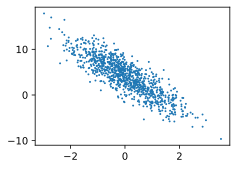

In [64]:
# 可视化：横轴为特征 X 第二列，纵轴为标签 y，可见线性关系

d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);

In [65]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

In [66]:
# 测试迭代器：取出第一个小批量查看内容

batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[-1.3405,  1.4891],
        [ 0.7679,  0.4023],
        [-0.5641,  2.2416],
        [ 3.0383,  1.4219],
        [-1.9854,  0.4746],
        [ 0.1739, -0.5112],
        [-0.4158,  0.6102],
        [-0.3277, -0.8077],
        [ 0.2460, -1.0989],
        [ 0.1020, -1.3265]]) 
 tensor([[-3.5515],
        [ 4.3801],
        [-4.5704],
        [ 5.4668],
        [-1.3755],
        [ 6.3074],
        [ 1.2827],
        [ 6.2829],
        [ 8.4342],
        [ 8.9299]])


In [67]:
# 初始化可学习参数 w、b，并开启梯度追踪 (requires_grad=True)

w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

In [68]:
def linreg(X, w, b):  #@save
    """线性回归模型"""
    return torch.matmul(X, w) + b

In [69]:
def squared_loss(y_hat, y):  #@save
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

In [70]:
def sgd(params, lr, batch_size):  #@save
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

In [71]:
# 训练循环：多轮(epoch)中反复取小批量 -> 算损失 -> 反向传播 -> SGD 更新参数

lr = 0.02
num_epochs = 6
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)  # X和y的小批量损失
        # 因为l形状是(batch_size,1)，而不是一个标量。l中的所有元素被加到一起，
        # 并以此计算关于[w,b]的梯度
        l.sum().backward()
        sgd([w, b], lr, batch_size)  # 使用参数的梯度更新参数
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.293709
epoch 2, loss 0.005352
epoch 3, loss 0.000147
epoch 4, loss 0.000049
epoch 5, loss 0.000048
epoch 6, loss 0.000048


In [72]:
# 对比估计参数与真实参数的误差

print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([0.0002, 0.0001], grad_fn=<SubBackward0>)
b的估计误差: tensor([-0.0005], grad_fn=<RsubBackward1>)
